In [ ]:
#Salaheddine Ezzaarate
#AI was used for debugging and tidying .
!pip install python-dotenv
!pip install pandas
!pip install requests
!pip install seaborn

import requests
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
import seaborn as sns


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
load_dotenv()
API_KEY = os.getenv("CENSUS_API_KEY")
API_KEY = "7f0d8ef63f0cb38b60e1eee995f5dc994f08b57b"

url = f"https://api.census.gov/data/2024/acs/acs5/profile?get=NAME,DP03_0062E,DP04_0134E&for=county:*&in=state:37&key={API_KEY}"
response = requests.get(url)

data = response.json()
df = pd.DataFrame(data[1:], columns=data[0])

df = df.rename(columns={
    "DP03_0062E": "Median_Household_Income",
    "DP04_0134E": "Median_Gross_Rent"
})

print(df.shape)
print(df.isna().sum())

(100, 5)
NAME                       0
Median_Household_Income    0
Median_Gross_Rent          0
state                      0
county                     0
dtype: int64


In [14]:
target_cols = ["Median_Household_Income", "Median_Gross_Rent"]
df[target_cols] = df[target_cols].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=target_cols)
print(df[["NAME", "Median_Household_Income", "Median_Gross_Rent"]].head())
print(df.head())

                               NAME  Median_Household_Income  \
0   Alamance County, North Carolina                    65651   
1  Alexander County, North Carolina                    65354   
2  Alleghany County, North Carolina                    47172   
3      Anson County, North Carolina                    47302   
4       Ashe County, North Carolina                    56866   

   Median_Gross_Rent  
0               1064  
1                764  
2                675  
3                814  
4                859  
                               NAME  Median_Household_Income  \
0   Alamance County, North Carolina                    65651   
1  Alexander County, North Carolina                    65354   
2  Alleghany County, North Carolina                    47172   
3      Anson County, North Carolina                    47302   
4       Ashe County, North Carolina                    56866   

   Median_Gross_Rent state county  
0               1064    37    001  
1                764

In [15]:
print(df[["Median_Household_Income", "Median_Gross_Rent"]].describe())
print("\nCorrelation Matrix:")
print(df[["Median_Household_Income", "Median_Gross_Rent"]].corr())

       Median_Household_Income  Median_Gross_Rent
count                100.00000          100.00000
mean               63181.72000          976.69000
std                13886.69788          230.90965
min                41685.00000          644.00000
25%                53532.00000          799.75000
50%                60229.50000          885.50000
75%                68157.75000         1131.00000
max               105768.00000         1627.00000

Correlation Matrix:
                         Median_Household_Income  Median_Gross_Rent
Median_Household_Income                 1.000000           0.815735
Median_Gross_Rent                       0.815735           1.000000


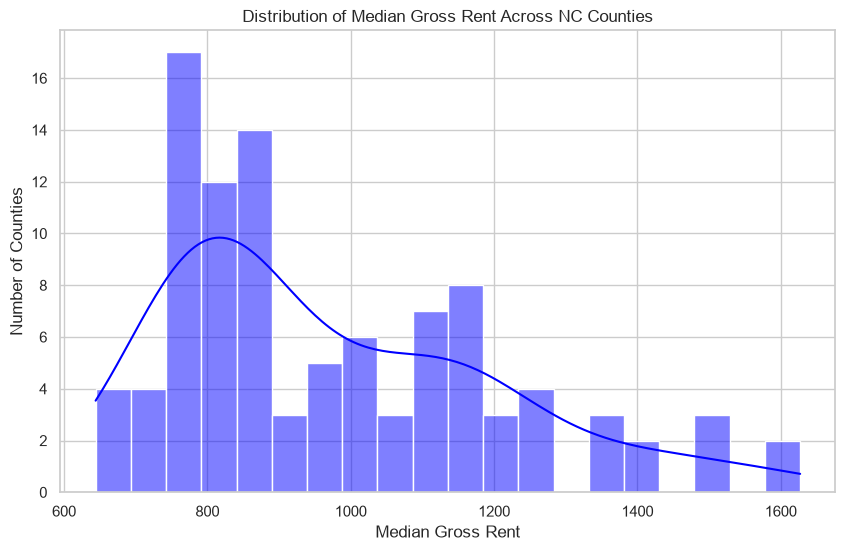

<Figure size 640x480 with 0 Axes>

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Median_Gross_Rent"],kde=True, color="blue", bins=20)
plt.title("Distribution of Median Gross Rent Across NC Counties")
plt.xlabel("Median Gross Rent")
plt.ylabel("Number of Counties")
plt.show()
plt.tight_layout()


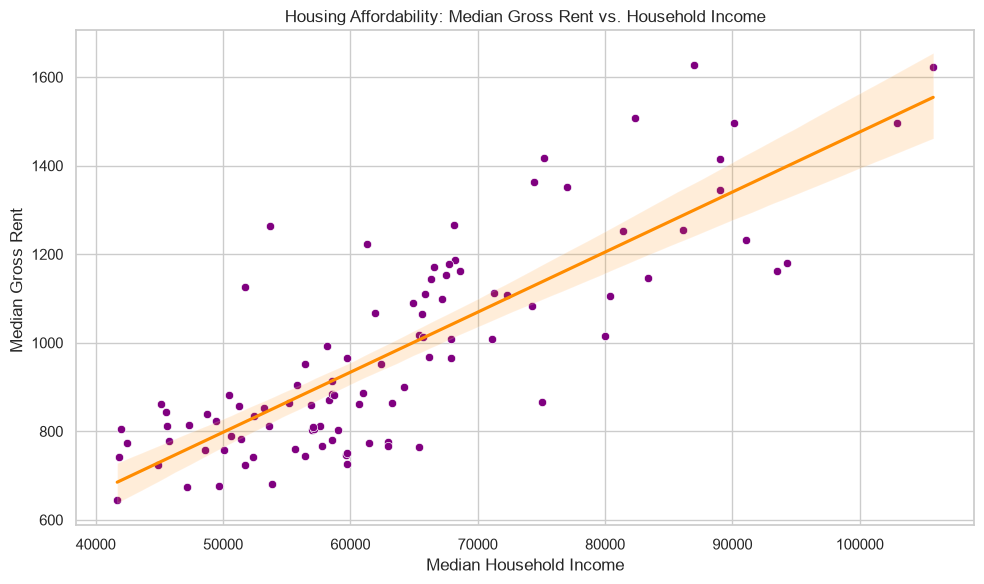

In [24]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Median_Household_Income", y="Median_Gross_Rent", color="purple",)
sns.regplot(data=df, x="Median_Household_Income", y="Median_Gross_Rent", scatter=False, color="darkorange")
plt.title("Housing Affordability: Median Gross Rent vs. Household Income")
plt.xlabel("Median Household Income")
plt.ylabel("Median Gross Rent ")
plt.tight_layout()
plt.show()